<h2 style="color:burlywood;">Distribusi dan Variabilitas Harga Produk Skincare</h2>

<h4 style="color:cadetblue;">Import Library</h4>

In [3]:
%matplotlib inline

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

<h4 style="color:cadetblue;">Lihat Struktur Dataset</h4>

In [7]:
df = pd.read_csv("product_info.csv")
df.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [8]:
df = pd.read_csv("product_info.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

<h4 style="color:cadetblue;">Pemilihan Variabel</h4>

In [16]:
df = df[["product_name", 
         "price_usd", 
         "brand_name", 
         "rating", 
         "primary_category", 
         "secondary_category", 
         "reviews", 
         "loves_count"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_name        8494 non-null   object 
 1   price_usd           8494 non-null   float64
 2   brand_name          8494 non-null   object 
 3   rating              8216 non-null   float64
 4   primary_category    8494 non-null   object 
 5   secondary_category  8486 non-null   object 
 6   reviews             8216 non-null   float64
 7   loves_count         8494 non-null   int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 531.0+ KB


Pemilihan ini dilakukan agar analisis lebih terfokus dan tidak terganggu oleh kolom-kolom yang tidak relevan dengan topik utama, yaitu: distribusi dan variabilitas harga produk skincare

<h4 style="color:cadetblue;">Data Wrangling</h4>

In [9]:
df.isnull().sum()

product_name            0
price_usd               0
brand_name              0
rating                278
primary_category        0
secondary_category      8
reviews               278
loves_count             0
dtype: int64

Berdasarkan hasil pengecekan missing values, terdapat beberapa kolom yang memiliki data kosong, yaitu pada kolom `rating`, `reviews`, dan `secondary_category`.
Kolom `rating` dan `reviews` masing-masing memiliki 278 data kosong, sedangkan `secondary_category` memiliki 8 data kosong. Sementara itu, kolom lainnya tidak memiliki missing values.
Keberadaan missing values dapat memengaruhi proses analisis data sehingga perlu dilakukan penanganan data terlebih dahulu pada tahap data wrangling.

In [19]:
df["rating"] = df["rating"].fillna(df["rating"].mean())

Pada tahap data wrangling, missing values pada kolom `rating` ditangani menggunakan metode imputasi mean. Nilai kosong diisi dengan rata-rata nilai rating sehingga data tetap dapat digunakan dalam proses analisis tanpa menghapus baris data yang memiliki nilai kosong.

In [20]:
df["reviews"] = df["reviews"].fillna(df["reviews"].median())

Missing values pada kolom `reviews` ditangani menggunakan metode imputasi median. Nilai kosong diisi dengan nilai median agar data tetap dapat digunakan tanpa terlalu dipengaruhi oleh nilai ekstrem atau outlier pada jumlah reviews.

In [21]:
df = df.dropna(subset=["secondary_category"])

Missing values pada kolom `secondary_category` ditangani dengan menghapus baris data yang memiliki nilai kosong menggunakan metode `dropna()`. Langkah ini dilakukan karena jumlah data kosong pada kolom tersebut relatif sedikit sehingga tidak terlalu memengaruhi keseluruhan dataset.

In [22]:
df.isnull().sum()

product_name          0
price_usd             0
brand_name            0
rating                0
primary_category      0
secondary_category    0
reviews               0
loves_count           0
dtype: int64

Setelah proses data wrangling dilakukan, seluruh kolom pada dataset sudah tidak memiliki missing values. Hal ini menunjukkan bahwa data telah bersih dan siap digunakan untuk proses analisis statistik serta visualisasi data.

In [23]:
df.duplicated().sum()

np.int64(0)

Berdasarkan hasil pengecekan menggunakan `duplicated().sum()`, diperoleh hasil 0. Hal ini menunjukkan bahwa tidak terdapat data duplikat pada dataset sehingga data sudah cukup bersih untuk digunakan dalam proses analisis.

<h4 style="color:cadetblue;">Deskriptif Statistik</h4>

In [24]:
df.describe()

,price_usd,rating,reviews,loves_count
count,8486.000000,8486.000000,8486.000000,8.486000e+03
mean,51.656330,4.194268,437.620787,2.920143e+04
std,53.689073,0.508231,1084.704243,6.611866e+04
min,3.000000,1.000000,1.000000,0.000000e+00
25%,25.000000,4.000000,28.000000,3.764000e+03
50%,35.000000,4.270800,122.000000,9.885500e+03
75%,58.000000,4.522000,402.000000,2.687025e+04
max,1900.000000,5.000000,21281.000000,1.401068e+06


Berdasarkan hasil statistik deskriptif, dataset terdiri dari 8.486 produk skincare. Rata-rata harga produk berada pada 51.66 USD dengan harga minimum 3 USD dan maksimum 1900 USD, sehingga terlihat adanya perbedaan harga yang cukup besar antar produk.
Nilai rating produk memiliki rata-rata 4.19 dengan standar deviasi yang kecil, sehingga dapat disimpulkan bahwa sebagian besar produk memiliki rating yang cukup tinggi dan stabil.
Pada variabel `reviews` dan `loves_count`, terdapat perbedaan yang cukup besar antara nilai minimum dan maksimum. Hal ini menunjukkan bahwa beberapa produk memiliki jumlah reviews dan likes yang sangat tinggi dibanding produk lainnya.

<h5 style="color:pink;">Ukuran Pemusatan Data</h5>

In [29]:
mean_price = df['price_usd'].mean()
mean_rating = df['rating'].mean()
mean_reviews = df['reviews'].mean()
mean_loves_count = df['loves_count'].mean()

median_price = df['price_usd'].median()
median_rating = df['rating'].median()
median_reviews = df['reviews'].median()
median_loves_count = df['loves_count'].median()

mode_price = df['price_usd'].mode()[0]
mode_rating = df['rating'].mode()[0]
mode_reviews = df['reviews'].mode()[0]
mode_loves_count = df['loves_count'].mode()[0]

print("Ukuran Pemusatan Data")
print(f"Mean Price : {mean_price:.2f}")
print(f"Mean Rating : {mean_rating:.2f}")
print(f"Mean Reviews : {mean_reviews:.2f}")
print(f"Mean Loves Count : {mean_loves_count:.2f}")

print(f"\nMedian Price : {median_price:.2f}")
print(f"Median Rating : {median_rating:.2f}")
print(f"Median Reviews : {median_reviews:.2f}")
print(f"Median Loves Count : {median_loves_count:.2f}")

print(f"\nModus Price : {mode_price:.2f}")
print(f"Modus Rating : {mode_rating:.2f}")
print(f"Modus Reviews : {mode_reviews:.2f}")
print(f"Modus Loves Count : {mode_loves_count:.2f}")

Ukuran Pemusatan Data
Mean Price : 51.66
Mean Rating : 4.19
Mean Reviews : 437.62
Mean Loves Count : 29201.43

Median Price : 35.00
Median Rating : 4.27
Median Reviews : 122.00
Median Loves Count : 9885.50

Modus Price : 30.00
Modus Rating : 4.19
Modus Reviews : 122.00
Modus Loves Count : 0.00


Berdasarkan hasil perhitungan, rata-rata harga produk skincare pada dataset adalah sekitar 51.66 USD dengan median sebesar 35 USD. Hal ini menunjukkan bahwa sebagian besar produk memiliki harga di bawah rata-rata karena terdapat beberapa produk dengan harga sangat tinggi.
Nilai rata-rata rating produk sebesar 4.19 menunjukkan bahwa mayoritas produk memiliki penilaian yang cukup baik dari pengguna. Selain itu, median dan modus rating yang tidak jauh berbeda menunjukkan bahwa data rating cukup stabil.
Pada variabel `reviews` dan `loves_count`, nilai mean lebih besar dibanding median. Hal ini menunjukkan adanya beberapa produk yang memiliki jumlah reviews dan likes sangat tinggi sehingga memengaruhi rata-rata data.

<h5 style="color:pink;">Ukuran Penyebaran Data</h5>

In [28]:
jangkauan_price = df['price_usd'].max() - df['price_usd'].min()
jangkauan_rating = df['rating'].max() - df['rating'].min()
jangkauan_reviews = df['reviews'].max() - df['reviews'].min()
jangkauan_loves_count = df['loves_count'].max() - df['loves_count'].min()

simpangan_rata_rata_price = np.mean(np.abs(df['price_usd'] - df['price_usd'].mean()))
simpangan_rata_rata_rating = np.mean(np.abs(df['rating'] - df['rating'].mean()))
simpangan_rata_rata_reviews = np.mean(np.abs(df['reviews'] - df['reviews'].mean()))
simpangan_rata_rata_loves_count = np.mean(np.abs(df['loves_count'] - df['loves_count'].mean()))

varians_price = df['price_usd'].var()
varians_rating = df['rating'].var()
varians_reviews = df['reviews'].var()
varians_loves_count = df['loves_count'].var()

std_price = df['price_usd'].std()
std_rating = df['rating'].std()
std_reviews = df['reviews'].std()
std_loves_count = df['loves_count'].std()

print("Ukuran Penyebaran Data (Dispersion)")
print(f"Jangkauan Price  : {jangkauan_price}")
print(f"Jangkauan Rating : {jangkauan_rating}")
print(f"Jangkauan Reviews  : {jangkauan_reviews}")
print(f"Jangkauan Loves Count : {jangkauan_loves_count}")

print(f"\nSimpangan Rata-rata Price : {simpangan_rata_rata_price:.2f}")
print(f"Simpangan Rata-rata Rating : {simpangan_rata_rata_rating:.2f}")
print(f"\nSimpangan Rata-rata Reviews : {simpangan_rata_rata_reviews:.2f}")
print(f"Simpangan Rata-rata Loves Count : {simpangan_rata_rata_loves_count:.2f}")

print(f"\nVarians Price : {varians_price:.2f}")
print(f"Varians Price : {varians_rating:.2f}")
print(f"Varians Reviews : {varians_reviews:.2f}")
print(f"Varians Loves Count : {varians_loves_count:.2f}")

print(f"\nStandar Deviasi Price : {std_price:.2f}")
print(f"Standar Deviasi Rating : {std_rating:.2f}")
print(f"Standar Deviasi Reviews : {std_reviews:.2f}")
print(f"Standar Deviasi Loves Count : {std_loves_count:.2f}")

Ukuran Penyebaran Data (Dispersion)
Jangkauan Price  : 1897.0
Jangkauan Rating : 4.0
Jangkauan Reviews  : 21280.0
Jangkauan Loves Count : 1401068

Simpangan Rata-rata Price : 32.24
Simpangan Rata-rata Rating : 0.37

Simpangan Rata-rata Reviews : 502.36
Simpangan Rata-rata Loves Count : 31439.56

Varians Price : 2882.52
Varians Price : 0.26
Varians Reviews : 1176583.30
Varians Loves Count : 4371676870.00

Standar Deviasi Price : 53.69
Standar Deviasi Rating : 0.51
Standar Deviasi Reviews : 1084.70
Standar Deviasi Loves Count : 66118.66


Berdasarkan hasil perhitungan, data `price_usd`, `reviews`, dan `loves_count` memiliki penyebaran yang cukup besar. Hal ini terlihat dari nilai jangkauan, varians, dan standar deviasi yang tinggi.
Variabel `loves_count` memiliki penyebaran paling besar, yang menunjukkan bahwa jumlah likes antar produk sangat bervariasi. Sementara itu, variabel `rating` memiliki penyebaran yang kecil sehingga nilai rating produk cenderung stabil dan tidak terlalu berbeda jauh antar produk.
Secara keseluruhan, data pada dataset Sephora memiliki variasi yang cukup beragam, terutama pada harga, jumlah reviews, dan loves count.

<h5 style="color:pink;">Bentuk Distribusi Data</h5>

In [31]:
kemiringan_price = df['price_usd'].skew()
kemiringan_rating = df['rating'].skew()
kemiringan_reviews = df['reviews'].skew()
kemiringan_loves_count = df['loves_count'].skew()

keruncingan_price = df['price_usd'].kurt()
keruncingan_rating = df['rating'].kurt()
keruncingan_reviews= df['reviews'].kurt()
keruncingan_loves_count = df['loves_count'].kurt()

print("Bentuk Distribusi Data")
print(f"Kemiringan Price: {kemiringan_price:.2f}")
print(f"Kemiringan Rating: {kemiringan_rating:.2f}")
print(f"Kemiringan Reviews: {kemiringan_reviews:.2f}")
print(f"Kemiringan Loves Count: {kemiringan_loves_count:.2f}")

print(f"\nKeruncingan Price: {keruncingan_price:.2f}")
print(f"Keruncingan Rating: {keruncingan_rating:.2f}")
print(f"Keruncingan Reviews: {keruncingan_reviews:.2f}")
print(f"Keruncingan Loves Count: {keruncingan_loves_count:.2f}")

Bentuk Distribusi Data
Kemiringan Price: 7.38
Kemiringan Rating: -1.54
Kemiringan Reviews: 8.02
Kemiringan Loves Count: 7.25

Keruncingan Price: 175.63
Keruncingan Rating: 4.57
Keruncingan Reviews: 95.28
Keruncingan Loves Count: 81.90


1. Untuk harga produk skincare, skewness positif adalah hal yang wajar ada sejumlah kecil produk mahal dengan harga sangat tinggi yang menciptakan ekor panjang di sisi kanan distribusi.

2. Kurtosis tinggi pada distribusi harga mengindikasikan mayoritas produk terkonsentrasi di rentang harga tertentu, namun terdapat sejumlah produk dengan harga yang sangat jauh dari rata-rata.

<h4 style="color:cadetblue;">Distribusi Probabilitas & Visualisasi Data</h4>

<h5 style="color:pink;">Histogram</h5>

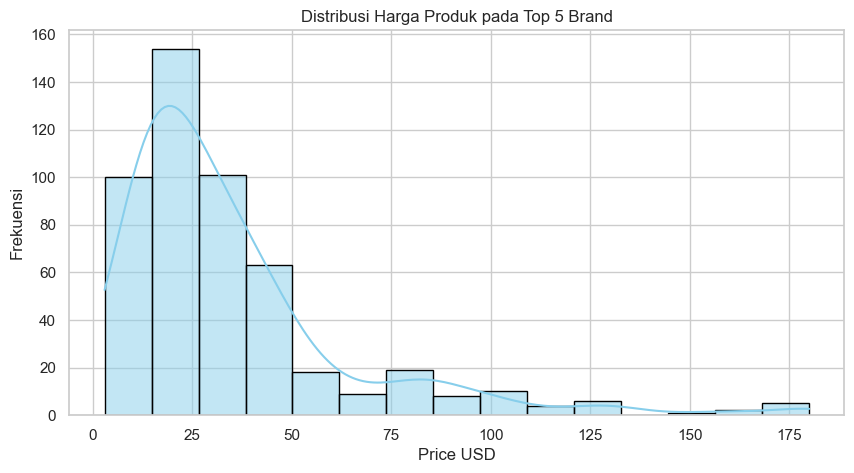

In [14]:
#Distribusi Harga Produk pada Top 5 Brand

top_brand = df['brand_name'].value_counts().head(5).index
sample_brand = df[df['brand_name'].isin(top_brand)]
sample_brand = sample_brand.sample(500, random_state=42)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))

sns.histplot(sample_brand['price_usd'], bins=15, color='skyblue', edgecolor='black', kde= True)

plt.title('Distribusi Harga Produk pada Top 5 Brand')
plt.xlabel('Price USD')
plt.ylabel('Frekuensi')

plt.show()

Mayoritas batang histogram menumpuk di sisi kiri dan kemudian ekornya memanjang ke kanan, hal ini mengonfirmasi distribusi harga yang right-skewed sebagian besar produk dari top brand ini berada di rentang harga menengah ke bawah, namun ada sejumlah produk premium yang harganya jauh lebih tinggi dari rata-rata

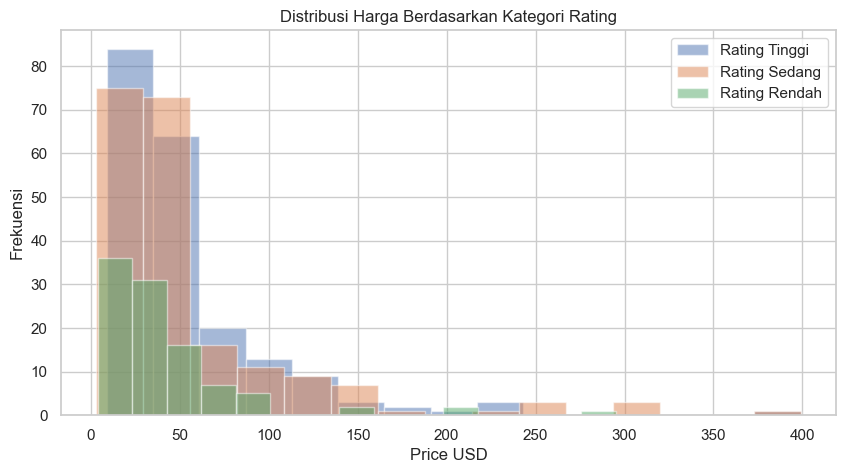

In [22]:
# Distribusi Harga Berdasarkan Kategori Rating

rating_tinggi = df[df['rating'] >= 4.5]
rating_sedang = df[(df['rating'] >= 3.5) & (df['rating'] < 4.5)]
rating_rendah = df[df['rating'] < 3.5]

rating_tinggi = rating_tinggi.sample(200, random_state=42)
rating_sedang = rating_sedang.sample(200, random_state=42)
rating_rendah = rating_rendah.sample(100, random_state=42)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))

plt.hist(
    rating_tinggi['price_usd'],
    bins=15,
    alpha=0.5,
    label='Rating Tinggi'
)

plt.hist(
    rating_sedang['price_usd'],
    bins=15,
    alpha=0.5,
    label='Rating Sedang'
)

plt.hist(
    rating_rendah['price_usd'],
    bins=15,
    alpha=0.5,
    label='Rating Rendah'
)

plt.title('Distribusi Harga Berdasarkan Kategori Rating')
plt.xlabel('Price USD')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

Histogram menunjukkan distribusi nilai rating produk skincare pada dataset Sephora. Terlihat bahwa sebagian besar produk memiliki rating tinggi, yaitu berada pada rentang 4 hingga 5. Hal ini menunjukkan bahwa mayoritas produk mendapatkan ulasan positif dari pengguna.
Distribusi data juga tampak tidak merata karena lebih banyak data terkumpul di sisi kanan grafik, sehingga dapat dikatakan distribusi cenderung miring ke kiri (negative skew).

<h5 style="color:pink;">Simulasi Monte Carlo</h5>

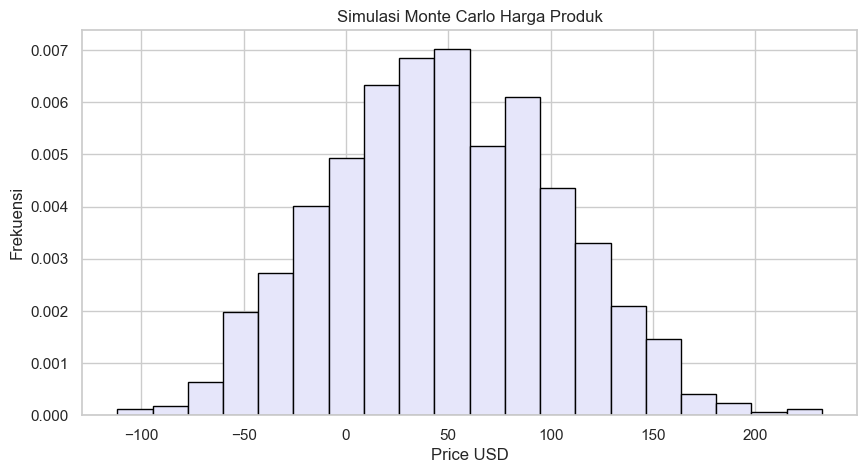

In [14]:
simulasi = np.random.normal(loc=df["price_usd"].mean(), scale=df["price_usd"].std(), size = 1000)

plt.figure(figsize=(10,5))
plt.hist(simulasi, bins = 20, color = 'lavender', edgecolor = 'black', density = True)
plt.title("Simulasi Monte Carlo Harga Produk")
plt.xlabel("Price USD")
plt.ylabel("Frekuensi")
plt.show()

Simulasi Monte Carlo digunakan untuk memodelkan kemungkinan distribusi harga produk skincare berdasarkan nilai rata-rata dan standar deviasi pada dataset. Simulasi dilakukan dengan menghasilkan 1000 data acak yang mengikuti distribusi normal.
Berdasarkan histogram, terlihat bahwa sebagian besar hasil simulasi terkonsentrasi di sekitar nilai tengah (mean), sedangkan jumlah data semakin berkurang pada bagian harga yang terlalu rendah maupun terlalu tinggi.
Penggunaan `density=True` pada histogram menunjukkan distribusi probabilitas data, sehingga grafik tidak hanya menampilkan frekuensi tetapi juga pola kemungkinan penyebaran harga produk skincare.

<h5 style="color:pink;">Boxplot</h5>

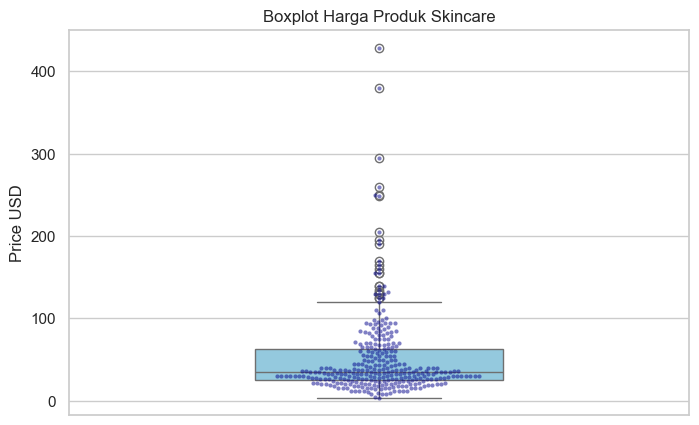

In [31]:
#Boxplot harga produk skincare
sample_price = df['price_usd'].sample(300, random_state=42)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

sns.boxplot(y=sample_price, color='skyblue', width=0.4)
sns.swarmplot(y=sample_price, color='darkblue', alpha=0.5, size=3)
plt.title('Boxplot Harga Produk Skincare')
plt.ylabel('Price USD')
plt.show()

Titik-titik yang berada jauh di atas bagian utama boxplot menunjukkan adanya produk dengan harga ekstrem dibandingkan sebagian besar produk lainnya. Hal ini menandakan adanya outlier pada data harga produk skincare Sephora. Keberadaan outlier ini juga dapat menyebabkan nilai mean harga menjadi lebih tinggi dibanding median.

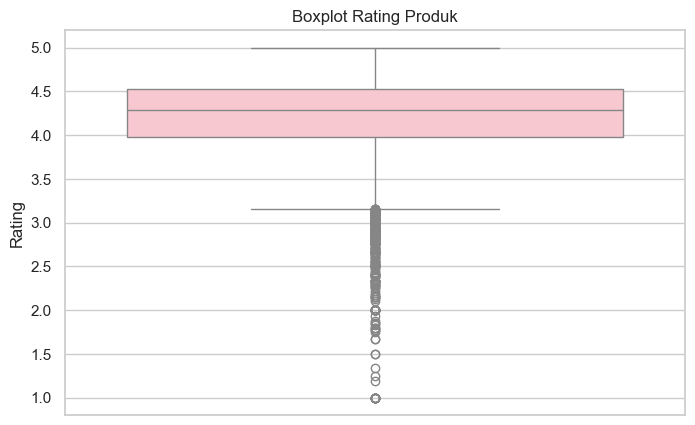

In [20]:
#Boxplot Rating
sample_price = df['rating'].sample(300, random_state=42)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

sns.boxplot(y=df["rating"], color="pink")

plt.title("Boxplot Rating Produk")
plt.ylabel("Rating")
plt.show()

Boxplot digunakan untuk melihat penyebaran data rating serta mendeteksi adanya outlier. Dari visualisasi terlihat bahwa sebagian besar rating berada pada rentang yang cukup tinggi dengan median yang mendekati nilai maksimum.
Terdapat beberapa titik di luar whisker yang menunjukkan adanya produk dengan rating yang jauh lebih rendah dibanding mayoritas produk lainnya.

<h5 style="color:pink;">Scatterplot</h5>

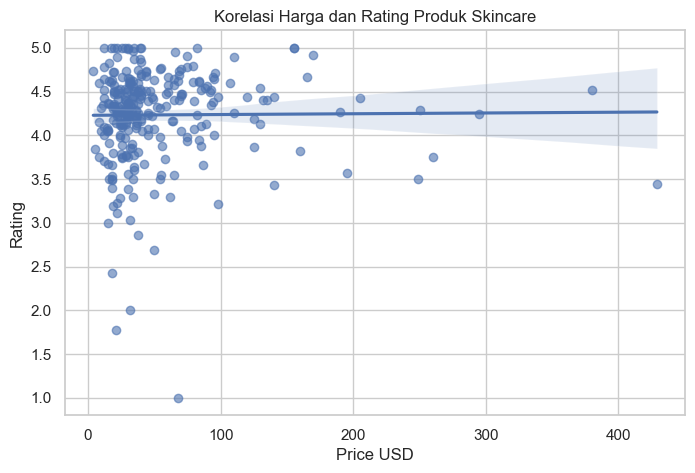

In [25]:
#Scatterplot harga vs rating

df_sample = df.sample(300, random_state=42)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

sns.regplot(
    data=df_sample,
    x='price_usd',
    y='rating',
    scatter_kws={'alpha':0.6}
)

plt.title("Korelasi Harga dan Rating Produk Skincare")
plt.xlabel("Price USD")
plt.ylabel("Rating")
plt.show()

Berdasarkan visualisasi, terlihat bahwa titik-titik data menyebar cukup luas dan tidak membentuk pola yang sangat kuat.
Garis regresi menunjukkan adanya kecenderungan hubungan positif, yaitu semakin tinggi harga produk maka rating produk cenderung sedikit meningkat. Namun, hubungan tersebut tidak terlalu signifikan karena banyak produk dengan harga rendah maupun tinggi sama-sama memiliki rating yang baik.
Hal ini menunjukkan bahwa harga produk tidak sepenuhnya menentukan tingkat kepuasan pengguna terhadap produk skincare.

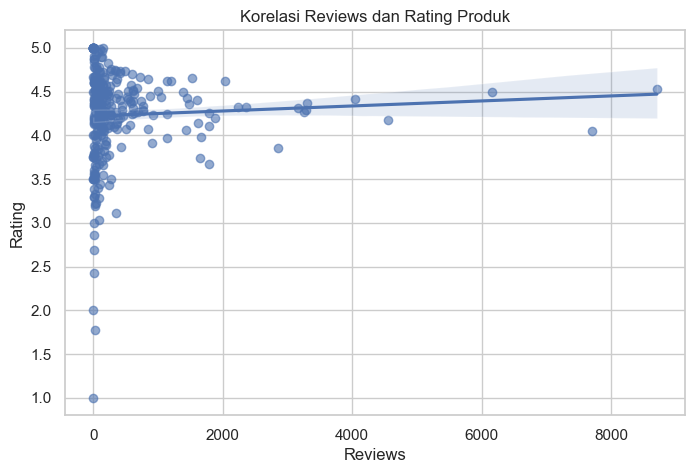

In [24]:
#Scatterplot reviews vs rating
df_sample = df.sample(300, random_state=42)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

sns.regplot(data=df_sample, x='reviews', y='rating', scatter_kws={'alpha':0.6})

plt.title("Korelasi Reviews dan Rating Produk")
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.show()

Berdasarkan visualisasi, terlihat bahwa data menyebar cukup luas namun terdapat kecenderungan hubungan positif antara kedua variabel.
Garis regresi menunjukkan bahwa produk dengan jumlah reviews yang lebih banyak cenderung memiliki rating yang lebih tinggi. Hal ini dapat menunjukkan bahwa produk yang populer dan sering digunakan pengguna umumnya memperoleh penilaian yang baik.
Meskipun demikian, hubungan tersebut tidak terlalu kuat karena masih terdapat beberapa produk dengan jumlah reviews sedikit tetapi memiliki rating tinggi.

<h5 style="color:pink;">Barchart</h5>

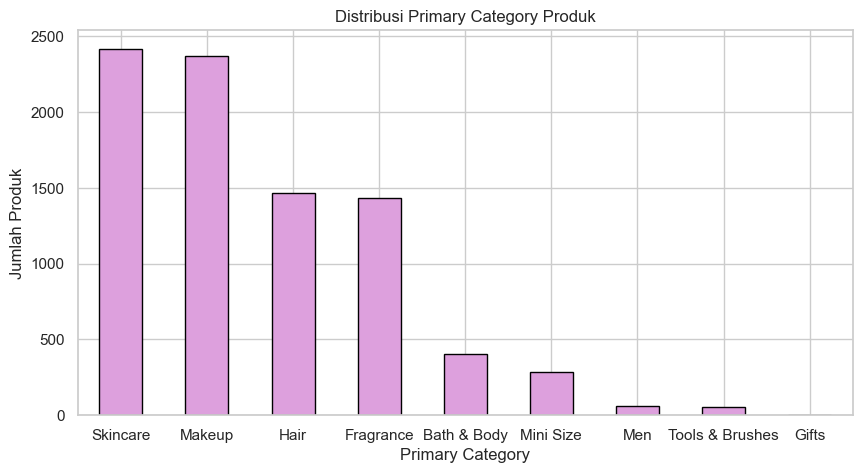

In [13]:
#primary category
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))

df["primary_category"].value_counts().plot(kind='bar', color='plum', edgecolor='black')

plt.title("Distribusi Primary Category Produk")
plt.xlabel("Primary Category")
plt.ylabel("Jumlah Produk")
plt.xticks(rotation=0)
plt.show()

Bar chart digunakan untuk melihat jumlah produk pada setiap primary category dalam dataset Sephora. Berdasarkan visualisasi, terlihat bahwa beberapa kategori memiliki jumlah produk yang jauh lebih banyak dibanding kategori lainnya.
Kategori dengan batang tertinggi menunjukkan bahwa kategori tersebut paling dominan dan memiliki jumlah produk terbanyak pada dataset. Sementara itu, kategori dengan batang lebih rendah menunjukkan jumlah produk yang lebih sedikit.
Pebedaan jumlah produk antar kategori menunjukkan bahwa distribusi data tidak merata dan terdapat kategori tertentu yang lebih populer atau lebih banyak dijual dibanding kategori lainnya.

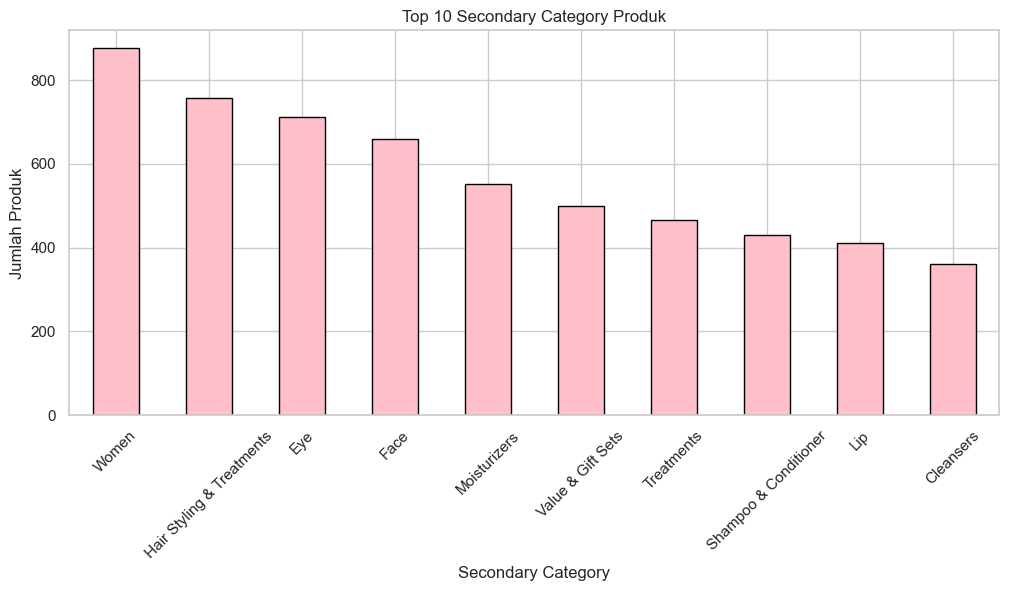

In [11]:
#secondary 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,5))

df["secondary_category"].value_counts().head(10).plot(kind='bar', color='pink', edgecolor='black')

plt.title("Top 10 Secondary Category Produk")
plt.xlabel("Secondary Category")
plt.ylabel("Jumlah Produk")
plt.xticks(rotation=45)
plt.show()

Berdasarkan visualisasi, terlihat bahwa beberapa secondary category memiliki jumlah produk yang lebih dominan dibanding kategori lainnya.
Kategori dengan jumlah produk tertinggi menunjukkan jenis produk yang paling banyak tersedia atau paling umum ditemukan dalam dataset. Sementara itu, kategori lain memiliki jumlah yang lebih sedikit namun tetap termasuk dalam 10 besar kategori terpopuler.
Visualisasi ini membantu memahami jenis produk skincare yang paling banyak dipasarkan dan menunjukkan bahwa distribusi produk antar secondary category tidak merata.